# README

### © Matteo Di Giovanni, Davide Rozza 2024

This code reads the modified ET sensitivity curves from .mat files and saves them into .txt filed to be read by the python code which makes the analysis.

This program is free software; you can redistribute it and/or
modify it under the terms of the GNU General Public License
as published by the Free Software Foundation; either version 2
of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program; if not, write to the Free Software
Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301,
USA.


In [12]:
import scipy.io
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os
import csv


def read_txt(filename):
    
    with open(filename) as inf:
        reader = csv.reader(inf, delimiter=" ")
        col_1 = list(zip(*reader))[0]
    col_1 = np.asarray(col_1, dtype=np.float32)
    
    with open(filename) as inf:
        reader = csv.reader(inf, delimiter=" ")
        col_2 = list(zip(*reader))[1]
    col_2 = np.asarray(col_2, dtype=np.float32)

    return col_1, col_2

## Read .mat files

In [13]:
# load ET computed with new NN
ET_Noise_file  = scipy.io.loadmat('../sens_curves/ETNoise_P2TERZ_1year.mat')
ET_Noise_f     = ET_Noise_file['ET_Noise_f'][0]
ASD_ETall      = ET_Noise_file['ASD_ETall'][0]
ASD_ET_P2_10   = ET_Noise_file['ASD_ET_P2_10'][0]
ASD_ET_P2_50   = ET_Noise_file['ASD_ET_P2_50'][0]
ASD_ET_P2_90   = ET_Noise_file['ASD_ET_P2_90'][0]
ASD_ET_TERZ_10 = ET_Noise_file['ASD_ET_TERZ_10'][0]
ASD_ET_TERZ_50 = ET_Noise_file['ASD_ET_TERZ_50'][0]
ASD_ET_TERZ_90 = ET_Noise_file['ASD_ET_TERZ_90'][0]

# READS ET DESIGN CURVE AS A REFERENCE

freq, ETD      = read_txt('../sens_curves/ET-0000A-18_ETDSensitivityCurveTxtFile.txt')

In [14]:
# load ET computed with new NN
ET_Noise_file  = scipy.io.loadmat('../sens_curves/ETNoise_P2P3_JanJul.mat')
ET_Noise_f     = ET_Noise_file['ET_Noise_f'][0]
ASD_ET_P2_50   = ET_Noise_file['ASD_ETP2_Jul_50'][0]
ASD_ET_P2_50_jan   = ET_Noise_file['ASD_ETP2_Jan_50'][0]
# READS ET DESIGN CURVE AS A REFERENCE

freq, ETD      = read_txt('../sens_curves/ET-0000A-18_ETDSensitivityCurveTxtFile.txt')

In [15]:
ET_Noise_file

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Mon Mar 23 12:25:15 2026',
 '__version__': '1.0',
 '__globals__': [],
 'ET_Noise_f': array([[   1.        ,    1.00230601,    1.00461733, ...,  995.40388884,
          997.6992978 , 1000.        ]], shape=(1, 3000)),
 'ASD_ETP2_Jan_05': array([[4.45656125e-17, 4.63344728e-17, 4.82245223e-17, ...,
         5.21416015e-25, 5.22284129e-25,            nan]], shape=(1, 3000)),
 'ASD_ETP2_Jan_50': array([[4.45656148e-17, 4.63344749e-17, 4.82245243e-17, ...,
         5.21416015e-25, 5.22284129e-25,            nan]], shape=(1, 3000)),
 'ASD_ETP2_Jan_95': array([[4.45656209e-17, 4.63344806e-17, 4.82245296e-17, ...,
         5.21416015e-25, 5.22284129e-25,            nan]], shape=(1, 3000)),
 'ASD_ETP2_Jul_05': array([[4.45656122e-17, 4.63344724e-17, 4.82245220e-17, ...,
         5.21416015e-25, 5.22284129e-25,            nan]], shape=(1, 3000)),
 'ASD_ETP2_Jul_50': array([[4.45656126e-17, 4.63344728e-17, 4.82245223e-17, ...,
    

## Plot curves 

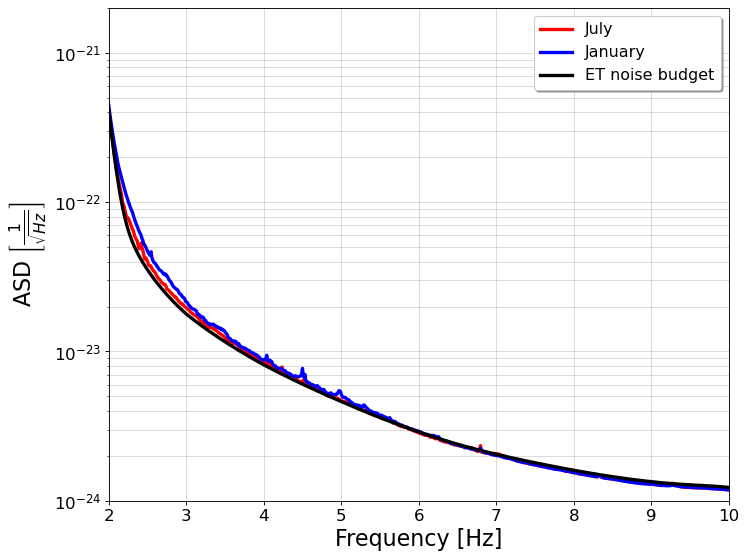

In [17]:
# Plot

fig, ax0=plt.subplots(figsize=(10, 8), dpi=80)
#ax0.plot(ET_Noise_f, ASD_ET_P2_10, label="P2 10 perc.", linewidth=2)
ax0.plot(ET_Noise_f, ASD_ET_P2_50, label="July", linewidth=3, color = 'r')
ax0.plot(ET_Noise_f, ASD_ET_P2_50_jan, label="January", linewidth=3, color = 'b')
#ax0.plot(ET_Noise_f, ASD_ET_P2_90, label="P2 90 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_10, label="TERZ 10 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_50, label="TERZ 50 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_90, label="TERZ 90 perc.", linewidth=2)
ax0.plot(ET_Noise_f, ASD_ETall, label="ET noise budget", linewidth=3, color = 'k')
ax0.tick_params(which='both',labelsize=15)
#ax0.set_xscale("log")
ax0.set_yscale("log")
ax0.set_xlabel('Frequency [Hz]', size = 20)
ax0.set_ylabel(r'ASD $\left [\frac{1}{\sqrt{Hz}} \right ]$', size = 20)
plt.grid(which="both", c='gray', lw=0.5, alpha=0.5)
plt.ylim([1e-24, 2e-21])
plt.xlim([2,10])
legend = ax0.legend(loc='upper right', shadow=True, fontsize='x-large')
fig.savefig('/users/matteodigiovanni/Downloads/sar_sens_jul_jan.png')
plt.show()




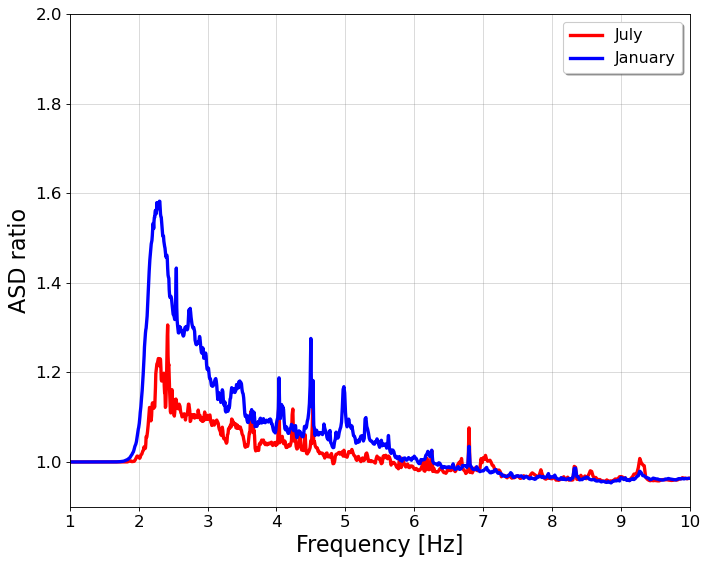

In [11]:
# Plot

fig, ax0=plt.subplots(figsize=(10, 8), dpi=80)
#ax0.plot(ET_Noise_f, ASD_ET_P2_10, label="P2 10 perc.", linewidth=2)
ax0.plot(ET_Noise_f, ASD_ET_P2_50/ASD_ETall, label="July", linewidth=3, color = 'r')
ax0.plot(ET_Noise_f, ASD_ET_P2_50_jan/ASD_ETall, label="January", linewidth=3, color = 'b')
#ax0.plot(ET_Noise_f, ASD_ET_P2_90, label="P2 90 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_10, label="TERZ 10 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_50, label="TERZ 50 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ET_TERZ_90, label="TERZ 90 perc.", linewidth=2)
#ax0.plot(ET_Noise_f, ASD_ETall, label="ET noise budget", linewidth=3, color = 'k')
ax0.tick_params(which='both',labelsize=15)
#ax0.set_xscale("log")
#ax0.set_yscale("log")
ax0.set_xlabel('Frequency [Hz]', size = 20)
ax0.set_ylabel(r'ASD ratio', size = 20)
plt.grid(which="both", c='gray', lw=0.5, alpha=0.5)
plt.ylim([0.9, 2])
plt.xlim([1,10])
legend = ax0.legend(loc='upper right', shadow=True, fontsize='x-large')
plt.show()
fig.savefig('/users/matteodigiovanni/Downloads/ratio_sens_jul_jan.png')



## Saves to .txt files

In [4]:
file = open('./sens_curves/ET_P2_90th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_90[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_P2_10th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], (ASD_ET_P2_10[k]))) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_P2_50th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_50[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_ALL_NB.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ETall[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_10th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_10[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_50th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_50[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_90th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_90[k])) for k in range(len(ET_Noise_f))]
file.close()

In [21]:
file = open('../sens_curves/ET_P2_50th_perc_jul.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_50[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('../sens_curves/ET_P2_50th_perc_jan.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_50_jan[k])) for k in range(len(ET_Noise_f))]
file.close()